# Cliff world 
### implementing the cliff world example from sutton and compairing Q learning and SARSA results

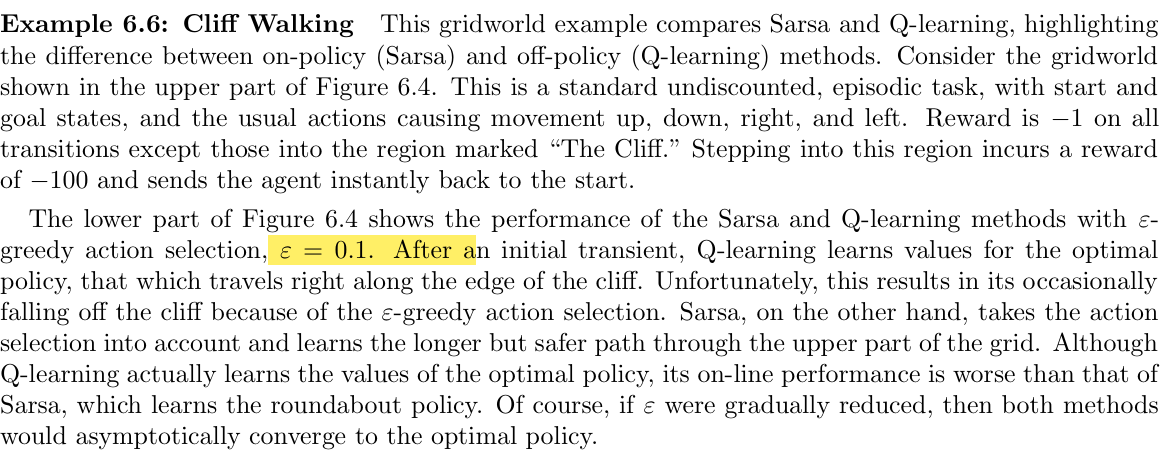

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [117]:
grid_size=(4,12)
cliff=(3, np.arange(1,11, dtype=int))

start=(3,0)
goal = (3, 11)

goal_reward=+10
penalty=-1
cliff_penalty=-100

e=.1

actions = [(-1, 0), (1, 0), (0, 1), (0, -1)]
actions_dict= ['N','S', 'E', 'W']
action_list = np.arange(0,4, dtype=int)

In [154]:
def next_reward(state, action):
    act=actions[action]
    new_state=(state[0]+act[0], state[1]+act[1])
    if new_state[0]<0 or new_state[1]<0 or new_state[0]>=grid_size[0] or new_state[1]>=grid_size[1]:
        return (state, -10)
    
    if new_state==goal:
        return (goal ,goal_reward)
    
    if new_state[0]==cliff[0] and new_state[1] in cliff[1]:
        return (start, cliff_penalty)
    
    return (new_state, penalty)

In [144]:
def e_greedy(Q, state):
    # pi= {1-e argmax(Q(s,a),a), e/|A| for all actions}
    A=len(action_list)
    outcomes=np.arange(0, A)
    prob= np.full(outcomes.size, e/A)
    prob[0]=1-e+e/A
    temp=np.argmax(Q[state])
    outcomes[0]=temp
    outcomes[temp]=0
    
    x=random.choices(outcomes, prob, k=1)
    return x[0]

In [ ]:
def Q_learn(iterations =500):
    Q=np.zeros((grid_size[0], grid_size[1], len(action_list)))
    N=np.ones((grid_size[0], grid_size[1], len(action_list)))
    t=0
    episodes=0
    rewards=[0]
    for _ in range(iterations):
        st=start
        sum=0
        while (True):
            at=e_greedy(Q, st)
            st1, rt=next_reward(st,at)
            sum=sum+rt

            Q[(st[0], st[1], at)]=Q[(st[0], st[1], at)]+(1/N[(st[0], st[1], at)])*(rt+np.max(Q[(st1)])-Q[(st[0], st[1], at)])
            N[(st[0], st[1], at)]+=1
            t=t+1
            st=st1
            if(st==goal):
                episodes+=1
                rewards.append(sum)
                break
        
    P=np.zeros(grid_size, dtype=str)
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            P[(i,j)]=actions_dict[np.argmax(Q[(i,j)])]
    return Q, P, rewards, t


In [174]:
Q_opt, P_opt,rewards, t=Q_learn()
np.set_printoptions(precision=3, suppress=True)
print(P_opt)
print(t)

[['S' 'E' 'E' 'E' 'E' 'S' 'S' 'S' 'S' 'S' 'W' 'W']
 ['E' 'E' 'E' 'E' 'E' 'E' 'S' 'E' 'S' 'S' 'S' 'S']
 ['E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'S']
 ['N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N']]
11112


In [191]:
def SARSA(iterations=500):
    Q=np.zeros((grid_size[0], grid_size[1], len(action_list)))
    N=np.ones((grid_size[0], grid_size[1], len(action_list)))
    t=0
    episodes=0
    rewards=[0]
    for _ in range(iterations):
        st=start
        at=e_greedy(Q, st)
        sum=0
        while (True):
            st1, rt=next_reward(st,at)
            at1=e_greedy(Q, st1)
            sum=sum+rt

            Q[(st[0], st[1], at)]=Q[(st[0], st[1], at)]+(1/N[(st[0], st[1], at)])*(rt+Q[(st1[0], st1[1], at1)]-Q[(st[0], st[1], at)])
            N[(st[0], st[1], at)]+=1
            t=t+1
            st=st1
            at=at1
            if(st==goal):
                episodes+=1
                rewards.append(sum)
                break
    P=np.zeros(grid_size, dtype=str)
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            P[(i,j)]=actions_dict[np.argmax(Q[(i,j)])]
    return Q, P, rewards, t

In [192]:
Q_opt_SARSA, P_opt_SARSA,rewards_SARSA, t_SARSA=SARSA()
np.set_printoptions(precision=3, suppress=True)
print(P_opt_SARSA)
print(t_SARSA)

[['E' 'S' 'S' 'E' 'S' 'E' 'S' 'S' 'S' 'S' 'S' 'S']
 ['E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'S']
 ['N' 'N' 'N' 'N' 'E' 'E' 'N' 'N' 'E' 'N' 'E' 'S']
 ['N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N']]
11673


#### NOTE the difference between the optimal policies learnt by SARSA and Q-learning
1) Q-learning learns the actual optimal policy the shortest path, which is walking right along the cliff
2) SARSA on the other hand learns the longer but safer way to reach the goal, i.e by avoiding the cliff and the boundry.

Due to the above, during training the Q_learning agent will fall of the cliff more often than the SARSA agent, thus making SARSA having a better online performance 
(NOTE: the iterations are NOT Greedy in the limit of infinite expansion i.e. 'e' does not decay overtime, otherwise both would have asymtotically converged to the optimal policy)


(-500.0, 10.0)

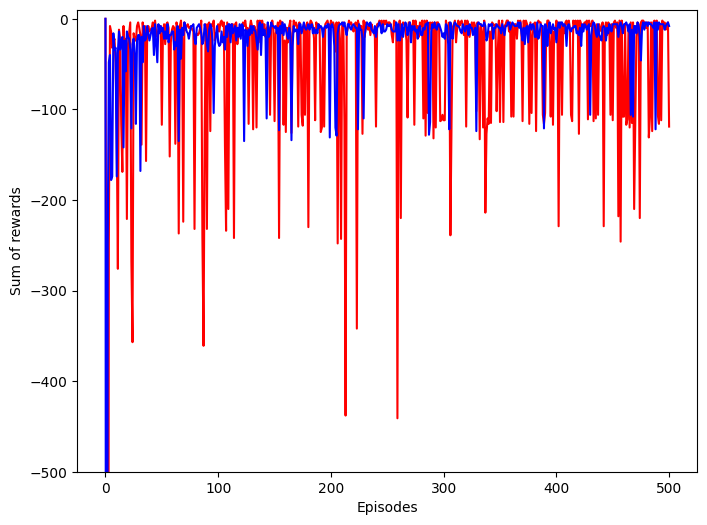

In [201]:
plt.figure(figsize=(8, 6))
plt.plot(np.arange(0,501), np.array(rewards), color='r', markersize=.1)
plt.plot(np.arange(0,501), np.array(rewards_SARSA), color='b',markersize=.1)
plt.xlabel('Episodes')
plt.ylabel('Sum of rewards')   
plt.ylim(-500, 10)

# the large dips in q_learning agents performance shows the times it fell into the cliff
